# Notebook 2: Implementacja modeli

## Analiza sentymentu angielskich recenzji aplikacji Spotify

W tym notebooku implementujemy dwa podejścia do klasyfikacji sentymentu:

1. **Podejście klasyczne:** TF-IDF + SVM / Naive Bayes
2. **Podejście Transformer:** Fine-tuning modelu DestilBERT

Dane pochodzą z Notebooka 1.

## 1. Instalacja bibliotek i import

In [20]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn sympy -q

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Wczytanie danych

In [22]:
# Wczytaj dane przygotowane w Notebooku 1
# W Google Colab: najpierw prześlij pliki CSV lub zamontuj Google Drive
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Kolumny
TEXT_COL = "text"        # oryginalny tekst (dla Transformerów)
CLEAN_COL = "text_clean"  # przetworzony tekst (dla podejścia klasycznego)
LABEL_COL = "sentiment"

Train: 3500, Val: 750, Test: 750


---
## CZĘŚĆ A: Podejście klasyczne (TF-IDF + klasyfikatory)

Implementujemy pipeline: TF-IDF → klasyfikator (SVM, Naive Bayes, Logistic Regression)

In [23]:
# Przygotowanie danych dla podejścia klasycznego
X_train_clean = train_df[CLEAN_COL].fillna("").values
X_val_clean = val_df[CLEAN_COL].fillna("").values
X_test_clean = test_df[CLEAN_COL].fillna("").values

y_train = train_df[LABEL_COL].values
y_val = val_df[LABEL_COL].values
y_test = test_df[LABEL_COL].values

In [24]:
# Wektoryzacja TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  # unigramy i bigramy
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"Wymiary macierzy TF-IDF (train): {X_train_tfidf.shape}")
print(f"Liczba cech (unikalne n-gramy): {X_train_tfidf.shape[1]}")

Wymiary macierzy TF-IDF (train): (3500, 5420)
Liczba cech (unikalne n-gramy): 5420


In [25]:
# Trening klasyfikatorów klasycznych
classifiers = {
    "SVM (LinearSVC)": LinearSVC(max_iter=5000, random_state=42),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}

classic_results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Trening: {name}")
    print(f"{'='*50}")

    # Trening
    clf.fit(X_train_tfidf, y_train)

    # Predykcja na zbiorze walidacyjnym
    y_val_pred = clf.predict(X_val_tfidf)

    # Metryki
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="weighted")

    classic_results[name] = {
        "model": clf,
        "val_accuracy": acc,
        "val_f1": f1,
        "val_predictions": y_val_pred,
    }

    print(f"Accuracy (val): {acc:.4f}")
    print(f"F1-score (val): {f1:.4f}")
    print(f"\nRaport klasyfikacji (val):")
    print(
        classification_report(
            y_val, y_val_pred, target_names=["Negatywny", "Pozytywny"]
        )
    )


Trening: SVM (LinearSVC)
Accuracy (val): 0.8467
F1-score (val): 0.8466

Raport klasyfikacji (val):
              precision    recall  f1-score   support

   Negatywny       0.80      0.80      0.80       287
   Pozytywny       0.88      0.88      0.88       463

    accuracy                           0.85       750
   macro avg       0.84      0.84      0.84       750
weighted avg       0.85      0.85      0.85       750


Trening: Naive Bayes
Accuracy (val): 0.8400
F1-score (val): 0.8403

Raport klasyfikacji (val):
              precision    recall  f1-score   support

   Negatywny       0.78      0.80      0.79       287
   Pozytywny       0.88      0.86      0.87       463

    accuracy                           0.84       750
   macro avg       0.83      0.83      0.83       750
weighted avg       0.84      0.84      0.84       750


Trening: Logistic Regression
Accuracy (val): 0.8667
F1-score (val): 0.8660

Raport klasyfikacji (val):
              precision    recall  f1-score   

In [26]:
# Wybór najlepszego klasyfikatora klasycznego
best_classic_name = max(classic_results, key=lambda x: classic_results[x]["val_f1"])
best_classic = classic_results[best_classic_name]

print(f"Najlepszy klasyfikator klasyczny: {best_classic_name}")
print(f"F1-score (val): {best_classic['val_f1']:.4f}")

# Ewaluacja na zbiorze testowym
y_test_pred_classic = best_classic["model"].predict(X_test_tfidf)
classic_test_acc = accuracy_score(y_test, y_test_pred_classic)
classic_test_f1 = f1_score(y_test, y_test_pred_classic, average="weighted")

print(f"\nWyniki na zbiorze testowym ({best_classic_name}):")
print(f"Accuracy: {classic_test_acc:.4f}")
print(f"F1-score: {classic_test_f1:.4f}")
print(f"\nRaport klasyfikacji (test):")
print(
    classification_report(
        y_test, y_test_pred_classic, target_names=["Negatywny", "Pozytywny"]
    )
)

Najlepszy klasyfikator klasyczny: Logistic Regression
F1-score (val): 0.8660

Wyniki na zbiorze testowym (Logistic Regression):
Accuracy: 0.8667
F1-score: 0.8667

Raport klasyfikacji (test):
              precision    recall  f1-score   support

   Negatywny       0.83      0.83      0.83       287
   Pozytywny       0.89      0.89      0.89       463

    accuracy                           0.87       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.87      0.87      0.87       750



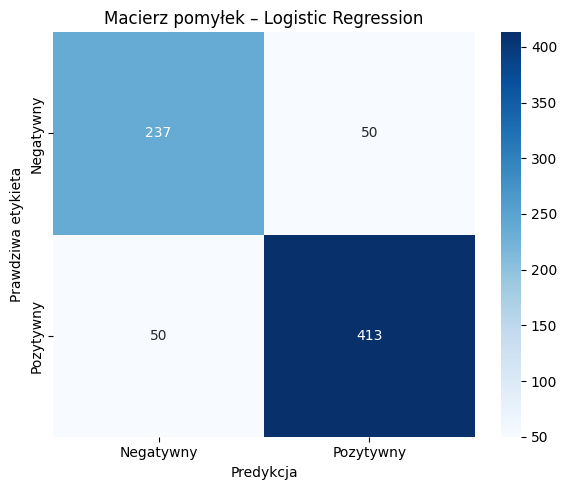

In [27]:
# Macierz pomyłek - podejście klasyczne
cm_classic = confusion_matrix(y_test, y_test_pred_classic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_classic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatywny", "Pozytywny"],
    yticklabels=["Negatywny", "Pozytywny"],
)
plt.title(f"Macierz pomyłek – {best_classic_name}")
plt.xlabel("Predykcja")
plt.ylabel("Prawdziwa etykieta")
plt.tight_layout()
plt.show()

---
## CZĘŚĆ B: Podejście oparte na Transformerach (DestilBERT)

Fine-tuning modelu [DestilBERT] szybszej i lżejszej wersji BERT która znajduje się na HuggingFace.

**Uwaga:** Uruchom ten fragment na GPU w Google Colab (Runtime → Change runtime type → GPU).

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# Sprawdzenie GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Urządzenie: cuda
GPU: Tesla T4


In [29]:
# Załadowanie tokenizatora i modelu HerBERT
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

print(f"Model: {MODEL_NAME}")
print(f"Parametry: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: distilbert-base-uncased
Parametry: 66,955,010


In [30]:
class SentimentDataset(Dataset):
    """Dataset dla recenzji z sentymentem."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label, dtype=torch.long),
        }

In [31]:
# Przygotowanie DataLoaderów (używamy surowego tekstu, nie przetworzonego)
MAX_LENGTH = 128
BATCH_SIZE = 16

train_dataset = SentimentDataset(
    train_df[TEXT_COL].values, train_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)
val_dataset = SentimentDataset(
    val_df[TEXT_COL].values, val_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)
test_dataset = SentimentDataset(
    test_df[TEXT_COL].values, test_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Batche treningowe: {len(train_loader)}")
print(f"Batche walidacyjne: {len(val_loader)}")

Batche treningowe: 219
Batche walidacyjne: 47


In [32]:
# Hiperparametry treningu
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

In [33]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Jedna epoka treningu."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    """Ewaluacja modelu."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids, attention_mask=attention_mask, labels=labels
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)

In [34]:
# Pętla treningowa
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Rozpoczynam trening DestilBERT ({EPOCHS} epok)...\n")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoka {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

Rozpoczynam trening DestilBERT (3 epok)...

Epoka 1/3 | Train Loss: 0.4085 | Train Acc: 0.7929 | Val Loss: 0.2951 | Val Acc: 0.8840 | Val F1: 0.8834
Epoka 2/3 | Train Loss: 0.2335 | Train Acc: 0.9180 | Val Loss: 0.2885 | Val Acc: 0.8947 | Val F1: 0.8945
Epoka 3/3 | Train Loss: 0.1685 | Train Acc: 0.9431 | Val Loss: 0.2915 | Val Acc: 0.9000 | Val F1: 0.8997


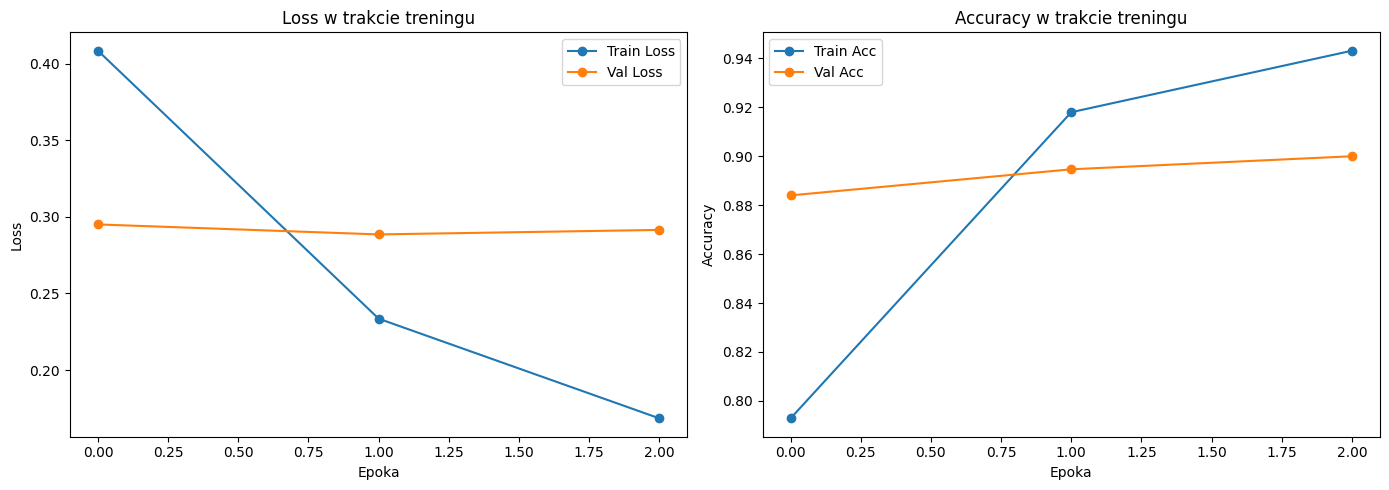

In [35]:
# Wykresy treningu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Loss w trakcie treningu")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(history["val_acc"], label="Val Acc", marker="o")
axes[1].set_title("Accuracy w trakcie treningu")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# Ewaluacja DestilBERT na zbiorze testowym
test_loss, test_acc, test_f1, y_test_pred_transformer, y_test_true = evaluate(
    model, test_loader, device
)

print(f"Wyniki DestilBERT na zbiorze testowym:")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"\nRaport klasyfikacji:")
print(
    classification_report(
        y_test_true, y_test_pred_transformer,
        target_names=["Negatywny", "Pozytywny"]
    )
)

Wyniki DestilBERT na zbiorze testowym:
Accuracy: 0.8920
F1-score: 0.8922

Raport klasyfikacji:
              precision    recall  f1-score   support

   Negatywny       0.85      0.87      0.86       287
   Pozytywny       0.92      0.90      0.91       463

    accuracy                           0.89       750
   macro avg       0.88      0.89      0.89       750
weighted avg       0.89      0.89      0.89       750



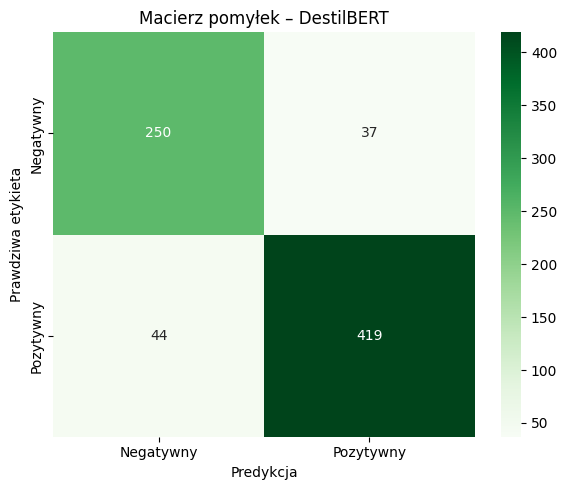

In [37]:
# Macierz pomyłek - Transformer
cm_transformer = confusion_matrix(y_test_true, y_test_pred_transformer)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negatywny", "Pozytywny"],
    yticklabels=["Negatywny", "Pozytywny"],
)
plt.title("Macierz pomyłek – DestilBERT")
plt.xlabel("Predykcja")
plt.ylabel("Prawdziwa etykieta")
plt.tight_layout()
plt.show()

In [38]:
# Zapis predykcji do pliku (do analizy w Notebooku 3)
results_df = test_df.copy()
results_df["pred_classic"] = y_test_pred_classic
results_df["pred_transformer"] = y_test_pred_transformer
results_df.to_csv("test_predictions.csv", index=False)

# Zapis podsumowania wyników
summary = {
    "classic_name": best_classic_name,
    "classic_accuracy": classic_test_acc,
    "classic_f1": classic_test_f1,
    "transformer_name": "DestilBERT",
    "transformer_accuracy": test_acc,
    "transformer_f1": test_f1,
}

with open("results_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

print("Predykcje zapisane do: test_predictions.csv")
print("Podsumowanie wyników zapisane do: results_summary.pkl")

Predykcje zapisane do: test_predictions.csv
Podsumowanie wyników zapisane do: results_summary.pkl


## Podsumowanie

W tym notebooku:
- Zaimplementowaliśmy podejście klasyczne: TF-IDF + SVM/Naive Bayes/Logistic Regression
- Zaimplementowaliśmy fine-tuning modelu DestilBERT (Transformer)
- Wyniki obu podejść zapisano do plików do dalszej analizy

Szczegółowe porównanie i analiza błędów znajdują się w Notebooku 3.